# Predicting Coral Reef Regimes from Human and Natural Influences
## 1. Project Title
**Notebook 01 — Multinomial Logistic Regression**

A machine-learning mini-project that predicts which of four **coral reef regimes** a reef site belongs to, using measurements of **human (anthropogenic)** and **natural (biophysical)** influences around the Hawaiian Islands.

The methodology follows the reference project ([Hawaii_RegimesPredictors](https://github.com/salliewalecka/Hawaii_RegimesPredictors), a Stanford CS229 class project built on Jouffray et al. 2019) as a **guide only**. We re-implement and run everything ourselves, so all results here are our own.

> **How to use this notebook:** click **Runtime → Run all**. Every number you see is *calculated by the code in this notebook* from the data — nothing is typed in by hand. All random seeds are fixed, so you will get the same numbers each time you run it.

## 2. Problem Statement

**Task:** *multi-class classification.* For each reef site we know 20 numbers describing human pressures (e.g. fishing, sedimentation, development) and natural conditions (e.g. sea-surface temperature, wave power, depth). We want a model that predicts the site's **reef regime** — one of four classes labelled **1, 2, 3 and 5** in the data.

**Model in this notebook:** *Multinomial Logistic Regression* — a simple, interpretable model that gives each regime a probability (using the *softmax* function) and picks the most probable one.

**Main evaluation metric:** **micro-average F1**, the metric emphasized in the reference project. (It is computed on the held-out test set.)

### Three ideas you need before we start

1. **Train / test split.** We hide a part of the data (the *test set*) and only look at it at the very end, to see how the model does on sites it has never seen. The model learns from the *training set* only.
2. **Data leakage.** If *anything* learned from the test data (for example the average used to fill missing values, or the mean used for scaling) sneaks into training, the test score becomes unrealistically good. We prevent this by learning every preprocessing step **only from the training data**.
3. **Pipeline.** A scikit-learn `Pipeline` chains the steps *fill missing values → scale → model* into one object. When we call `.fit()` on training data, every step learns from the training data only; when we later call `.predict()` on the test data, the steps just *apply* what they learned. This is the safest way to avoid leakage.

## 3. Dataset Description
The data come from the reference project's GitHub repository
([salliewalecka/Hawaii_RegimesPredictors](https://github.com/salliewalecka/Hawaii_RegimesPredictors), forked from the original
[JBjouffray/Hawaii_RegimesPredictors](https://github.com/JBjouffray/Hawaii_RegimesPredictors)), which accompanies
*Jouffray et al. (2019), "Parsing human and biophysical drivers of coral reef regimes", Proc. R. Soc. B 286: 20182544*.

**File used:** `Data/Hawaii_RegimesPredictors.txt` — the **raw** file (620 reef sites around the Hawaiian Islands, 39 columns, tab-separated, decimal comma).

> **Why not the `Hawaii_RegimesPredictors_complete.txt` file?** That file already has the missing values filled in, but the reference authors filled them using *all 620 sites before splitting the data* (and used a model that looked at columns that define the regimes). That would leak test-set information into training. We therefore start from the raw file and fill missing values ourselves, *inside the pipeline, using training data only*.

The 39 columns fall into five groups:

| Group | Columns | How we use them |
|---|---|---|
| Identifiers / location | `id_spatial`, `Long`, `Lat`, `Island` | **Not used** (not part of the reference's predictor set) |
| Reef community composition (10) | `Coral`, `CCA`, `Turf`, `Macro`, `Other`, `Grazers`, `Scrapers`, `Browsers`, `Predators`, `Secondary` | **Not used.** The regimes are *defined* from these fish and benthic measurements, so using them to predict the regime would be circular |
| **Anthropogenic predictors (10)** | `Effluent`, `Sedimentation`, `New_Development`, `Habitat_Modification`, `Invasive_Algae`, `Fishing_Comm_Total`, `Fishing_NonComm_Boat_Total`, `Fishing_NonComm_Shore_Line`, `Fishing_NonComm_Shore_Net`, `Fishing_NonComm_Shore_Spear` | **Features** |
| **Biophysical predictors (10)** | `SST_CLIM_M`, `SST_STD`, `CHL_CLIM_M`, `CHL_ANOM_F`, `PAR_CLIM_M`, `PAR_STD`, `WAV_CLIM_M`, `WAV_ANOM_F`, `Complexity`, `Depth` | **Features** |
| Target (5) | `Regime` (values 1, 2, 3, 5) plus `Regime1`, `Regime2`, `Regime3`, `Regime5` (the same label written as 0/1 columns) | **`Regime` is the target.** The four 0/1 columns are *copies of the answer*, so they must never be used as features |

The predictor groupings follow the repository's `Hawaii_PredictorsCategories.txt`. See the paper for the exact definitions of each variable.

## 4. Import Required Libraries

We import the tools we need and **fix the random seeds** so the results are reproducible.

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.base import clone
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, ConfusionMatrixDisplay)
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier

# ---- Reproducibility: fixed random seeds ----
SPLIT_RANDOM_STATE = 47   # same seed the reference project used for its train/test split
RANDOM_STATE = 42         # seed for cross-validation shuffling and for the models
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")

print("scikit-learn version:", sklearn.__version__)
print("pandas version      :", pd.__version__)

scikit-learn version: 1.6.1
pandas version      : 2.2.3


## 5. Load Dataset
We read the raw dataset directly from the reference GitHub repository.

* The file is **tab-separated** (`sep="\t"`) and uses a **decimal comma** (`decimal=","`), so we must tell pandas that.
* **If the download fails** (for example, no internet or a firewall), upload `Hawaii_RegimesPredictors.txt` to Colab's file panel (left sidebar → Files → Upload). The code below automatically uses `/content/Hawaii_RegimesPredictors.txt` if it exists. To use Google Drive instead, mount it and change `LOCAL_PATH` to your Drive path, e.g. `/content/drive/MyDrive/Hawaii_RegimesPredictors.txt`.

In [2]:
DATA_URL   = "https://raw.githubusercontent.com/salliewalecka/Hawaii_RegimesPredictors/master/Data/Hawaii_RegimesPredictors.txt"
LOCAL_PATH = "/content/Hawaii_RegimesPredictors.txt"   # used first if you uploaded the file yourself

data_source = LOCAL_PATH if os.path.exists(LOCAL_PATH) else DATA_URL
print("Reading data from:", data_source)

try:
    df = pd.read_csv(data_source, sep="\t", decimal=",")
except Exception as err:
    raise RuntimeError(
        "Could not read the dataset. Please download 'Data/Hawaii_RegimesPredictors.txt' from "
        "https://github.com/salliewalecka/Hawaii_RegimesPredictors and upload it to "
        "/content/Hawaii_RegimesPredictors.txt in Colab (or edit LOCAL_PATH above)."
    ) from err

# Safety checks: make sure we loaded the RAW file we expect (not a different/edited one)
assert df.shape == (620, 39), f"Unexpected shape {df.shape}; expected (620, 39). Is this the right file?"
assert "Regime" in df.columns, "Column 'Regime' not found - wrong file?"
assert df["Complexity"].isna().sum() > 0, "No missing values found - this looks like the '_complete' file, not the raw one."
print("Loaded OK:", df.shape[0], "rows x", df.shape[1], "columns")

Reading data from: https://raw.githubusercontent.com/salliewalecka/Hawaii_RegimesPredictors/master/Data/Hawaii_RegimesPredictors.txt
Loaded OK: 620 rows x 39 columns


## 6. Inspect Dataset

Let's take a first look at the data: its size, column types and first few rows.

In [3]:
print("Shape (rows, columns):", df.shape)
print()
print("Column data types:")
print(df.dtypes.value_counts().to_string())
print()
df.head()

Shape (rows, columns): (620, 39)

Column data types:
float64    30
int64       8
object      1



,id_spatial,Long,Lat,Island,Coral,CCA,Turf,Macro,Other,Grazers,Scrapers,Browsers,Predators,Secondary,Effluent,Sedimentation,New_Development,Habitat_Modification,Invasive_Algae,Fishing_Comm_Total,Fishing_NonComm_Boat_Total,Fishing_NonComm_Shore_Line,Fishing_NonComm_Shore_Net,Fishing_NonComm_Shore_Spear,SST_CLIM_M,SST_STD,CHL_CLIM_M,CHL_ANOM_F,PAR_CLIM_M,PAR_STD,WAV_CLIM_M,WAV_ANOM_F,Complexity,Depth,Regime,Regime1,Regime2,Regime3,Regime5
0,4,-157.307727,21.106717,Molokai,1.023891,1.706485,77.815700,18.088737,1.023891,1.324986,0.153250,0.163843,0.000000,3.393998,0.0,0.075594,0.004250,0,0,0.013817,0.396614,5.622424,3.671531,0.373111,27.474,0.956713,0.1213,0.0237,52.643398,8.5628,36.542160,0.083878,4.889608,2.8000,1,1,0,0,0
1,5,-157.304986,21.113497,Molokai,3.555556,1.333333,83.555556,9.777778,0.888889,0.890407,0.000000,0.248076,0.000000,2.872683,0.0,0.261318,0.004023,0,0,0.013817,0.386873,0.000000,0.000000,0.364839,27.474,0.956713,0.1213,0.0237,52.643398,8.5628,36.542160,0.083878,3.793523,7.3152,1,1,0,0,0
2,6,-157.303306,21.124814,Molokai,17.620555,6.348836,44.875760,25.716525,4.836712,4.628477,0.143309,5.420154,1.347466,2.238995,0.0,0.381684,0.003573,0,0,0.013817,0.377407,0.000000,0.000000,0.309139,27.474,0.956713,0.1154,0.0593,53.954201,9.4296,38.007866,0.084089,5.275938,11.5000,2,0,1,0,0
3,8,-157.299938,21.148297,Molokai,0.675676,1.351351,86.486487,0.337838,5.743243,0.069128,0.000000,0.000000,0.000000,3.341160,0.0,0.135392,0.000406,0,0,0.013817,0.353853,0.000000,0.000000,0.059943,27.474,0.956713,0.1154,0.0593,53.954201,9.4296,39.139775,0.087039,2.511288,29.1000,1,1,0,0,0
4,9,-157.300286,21.128897,Molokai,4.000000,3.111111,53.333333,17.333333,21.777778,11.775000,0.000000,1.655366,0.967914,8.411082,0.0,0.577138,0.003794,0,0,0.013817,0.369782,0.000000,0.000000,0.342674,27.474,0.956713,0.1154,0.0593,53.954201,9.4296,40.587803,0.084932,6.865359,10.0584,2,0,1,0,0


## 7. Identify Target and Features
* **Target (`y`)** — the column we want to predict: `Regime`.
* **Features (`X`)** — the 20 anthropogenic + biophysical predictor columns.
* **Everything else is deliberately left out** (see the table in section 3). In particular `Regime1`, `Regime2`, `Regime3`, `Regime5` are just the answer rewritten as 0/1, and the 10 community-composition columns are what the regimes are *made from* — using either would be cheating.

We build the feature list by **column name** (not by position) so the code cannot silently pick the wrong columns.

In [4]:
FEATURES = [
    # --- Anthropogenic (human) predictors ---
    "Effluent", "Sedimentation", "New_Development", "Habitat_Modification", "Invasive_Algae",
    "Fishing_Comm_Total", "Fishing_NonComm_Boat_Total", "Fishing_NonComm_Shore_Line",
    "Fishing_NonComm_Shore_Net", "Fishing_NonComm_Shore_Spear",
    # --- Biophysical (natural) predictors ---
    "SST_CLIM_M", "SST_STD", "CHL_CLIM_M", "CHL_ANOM_F", "PAR_CLIM_M", "PAR_STD",
    "WAV_CLIM_M", "WAV_ANOM_F", "Complexity", "Depth",
]

TARGET = "Regime"

ANTHROPOGENIC = FEATURES[:10]    # human influences
BIOPHYSICAL   = FEATURES[10:]    # natural influences

# Safety checks
assert all(c in df.columns for c in FEATURES), "A feature name is missing from the data"
assert TARGET not in FEATURES
assert not any(c.startswith("Regime") for c in FEATURES), "A target column leaked into the features!"

X = df[FEATURES].copy()
y = df[TARGET].copy()

class_labels = sorted(y.unique().tolist())
class_names  = [f"Regime {c}" for c in class_labels]

print("Number of samples (reef sites):", X.shape[0])
print("Number of features            :", X.shape[1],
      f"({len(ANTHROPOGENIC)} anthropogenic + {len(BIOPHYSICAL)} biophysical)")
print("Target classes                :", class_labels)
print()
class_counts = y.value_counts().sort_index()
pd.DataFrame({"sites": class_counts, "percent": (100 * class_counts / len(y)).round(1)})

Number of samples (reef sites): 620
Number of features            : 20 (10 anthropogenic + 10 biophysical)
Target classes                : [1, 2, 3, 5]



,sites,percent
Regime,,
1,171,27.6
2,172,27.7
3,143,23.1
5,134,21.6


In [5]:
# Summary statistics of the 20 predictor columns (we only LOOK here; nothing is learned or changed)
df[FEATURES].describe().T[["count", "mean", "std", "min", "50%", "max"]]

,count,mean,std,min,50%,max
Effluent,620.0,3827.363948,8556.137170,0.000000,481.001648,88142.132810
Sedimentation,620.0,6.905912,18.743726,0.000000,0.000555,171.111557
New_Development,620.0,0.025509,0.040390,0.000000,0.005849,0.376183
Habitat_Modification,620.0,0.083871,0.277418,0.000000,0.000000,1.000000
Invasive_Algae,620.0,0.212903,0.409690,0.000000,0.000000,1.000000
Fishing_Comm_Total,620.0,0.229942,0.435801,0.000000,0.066593,2.060731
Fishing_NonComm_Boat_Total,620.0,0.526341,0.747922,0.000000,0.301010,3.109559
Fishing_NonComm_Shore_Line,620.0,6.365645,9.469403,0.000000,0.000000,29.123327
Fishing_NonComm_Shore_Net,620.0,0.948522,1.465142,0.000000,0.000000,5.428471
Fishing_NonComm_Shore_Spear,620.0,2.370396,2.601515,0.000000,1.794678,7.422137


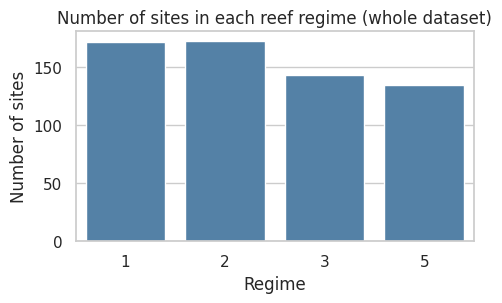

In [6]:
plt.figure(figsize=(5, 3.2))
sns.countplot(x=y, order=class_labels, color="steelblue")
plt.title("Number of sites in each reef regime (whole dataset)")
plt.xlabel("Regime"); plt.ylabel("Number of sites")
plt.tight_layout(); plt.show()

## 8. Handle Missing Values
First, let's see **which predictors have missing values and how many** (this only *counts* — nothing is learned from the data yet).

In [7]:
missing = X.isna().sum()
missing = missing[missing > 0]
pd.DataFrame({"missing values": missing, "percent of sites": (100 * missing / len(X)).round(1)})

,missing values,percent of sites
Complexity,113,18.2
Depth,12,1.9


Only `Complexity` and `Depth` have missing values. How did the reference project deal with them?

| Reference approach | What it did | Problem for us |
|---|---|---|
| `Baseline_Logistic_Model.ipynb` | Dropped rows with missing values, **or** filled with the **mean of the training data** | The mean-fill is fine and leak-free |
| `NA_estimation.ipynb` → `..._complete.txt` | `Depth`: filled with the **median**. `Complexity`: predicted with a **Lasso regression** trained on *all 620 sites*, using many other columns (including the community-composition columns that define the regimes) | Done **before** the train/test split, so test sites influenced the filled-in values (**data leakage**) |

**Our choice:** fill missing values with the **median of the training data**, using `SimpleImputer(strategy="median")` *inside the pipeline*.

* The median is a simple, robust choice (extreme values affect it less than the mean).
* Being inside the pipeline, the median is computed from **training rows only** (and, during cross-validation, from the training part of each fold only) and then re-used for the test rows.
* Honest caveat: about a fifth of the sites have no `Complexity` value, so a constant fill weakens that variable. This is a limitation we mention in the conclusion.

Below we only *define* the imputer (a recipe). It is **not fitted yet** — fitting happens after the split.

In [8]:
imputer = SimpleImputer(strategy="median")   # a recipe only - nothing has been learned yet
imputer

SimpleImputer(strategy='median')

## 9. Data Preprocessing
Our complete preprocessing recipe has just two steps, applied in this order:

1. **Impute** — fill missing values with the training-data median (section 8).
2. **Scale** — standardize every feature (section 11).

Categorical encoding (section 10) turns out not to be needed. The recipe will be placed inside a `Pipeline` together with the model, so it is always fitted on training data only.

## 10. Encode Categorical Variables
Machine-learning models need numbers. Let's check whether any predictor is text (a *categorical* variable) that would need encoding, e.g. with one-hot encoding.

In [9]:
non_numeric = X.select_dtypes(exclude="number").columns.tolist()
print("Non-numeric predictor columns:", non_numeric)
print()
# Two predictors are yes/no flags. Check how they are stored:
for col in ["Habitat_Modification", "Invasive_Algae"]:
    print(f"{col:22s} unique values: {sorted(X[col].unique().tolist())}")

Non-numeric predictor columns: []

Habitat_Modification   unique values: [0, 1]
Invasive_Algae         unique values: [0, 1]


**Result: no encoding is necessary.**

* All 20 predictors are already numeric.
* `Habitat_Modification` and `Invasive_Algae` are yes/no flags already stored as `0`/`1`. A binary flag *is* its own one-hot encoding (one-hot encoding would only add a redundant second column).
* `Island` (the only text column in the data) is **not** a predictor in the reference work, so we leave it out.
* The target `Regime` is already stored as numbers (1, 2, 3, 5); scikit-learn accepts these directly as class labels.

The reference project also treated those two flags as ordinary numbers and standardized all 20 columns together; we do the same so the two approaches are comparable.

## 11. Feature Scaling
**Standardization** rewrites each feature so that, *in the training data*, it has mean 0 and standard deviation 1: `z = (x − mean) / std`.

Let's look at how different the feature ranges are:


**Is scaling necessary for logistic regression? Yes.** Look at the table: `Effluent` spans tens of thousands while some flags span only 0 to 1.

* Our model uses **L2 regularization**, which penalizes large coefficients. A feature measured in huge units needs a tiny coefficient and a feature in small units needs a big one, so the penalty would treat features **unfairly** unless they share a common scale.
* The optimizer also converges faster and more reliably on standardized features.
* Scaling must be **learned from training data only** (mean and standard deviation), then applied to the test data. The pipeline takes care of this.

In [10]:
# We only LOOK at the ranges to see why scaling matters; nothing is fitted here.
ranges = X.agg(["min", "max"]).T
ranges["range"] = ranges["max"] - ranges["min"]
ranges.sort_values("range", ascending=False).round(3)

,min,max,range
Effluent,0.000,88142.133,88142.133
Sedimentation,0.000,171.112,171.112
WAV_CLIM_M,0.887,114.938,114.052
Complexity,0.000,35.868,35.868
Depth,0.488,30.000,29.512
Fishing_NonComm_Shore_Line,0.000,29.123,29.123
PAR_CLIM_M,36.232,56.417,20.185
Fishing_NonComm_Shore_Spear,0.000,7.422,7.422
Fishing_NonComm_Shore_Net,0.000,5.428,5.428
PAR_STD,6.825,11.714,4.890


In [11]:
scaler = StandardScaler()   # a recipe only - the mean/std are learned later, from training data only
scaler

# Our complete preprocessing recipe (still unfitted): impute, then scale
preprocessing = Pipeline([("imputer", imputer), ("scaler", scaler)])
preprocessing

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

## 12. Train/Test Split
We split the 620 sites into:

* **Training set (80%)** — the only data the model and the preprocessing steps learn from. We also run cross-validation *inside* this set to choose settings.
* **Test set (20%)** — locked away until the final evaluation.

We use the **same split as the reference project** (`test_size=0.2`, `random_state=47`). The reference additionally cut a validation set out of the training data and then merged it back for 5-fold cross-validation; our 5-fold cross-validation on the training set plays exactly the same role, so no separate validation set is needed.

> The reference split is *random* but **not stratified**, so the test set can have class proportions different from the whole dataset (we print them below). To use a stratified split instead, set `STRATIFY_SPLIT = True` — **but if you do, make sure your teammate does the same** so that all models are compared on identical test sites.

In [12]:
STRATIFY_SPLIT = False   # False = identical to the reference project's split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SPLIT_RANDOM_STATE,
    stratify=y if STRATIFY_SPLIT else None,
)

print("Total sites   :", len(X))
print("Training sites:", len(X_train), f"({100*len(X_train)/len(X):.0f}%)")
print("Test sites    :", len(X_test),  f"({100*len(X_test)/len(X):.0f}%)")
print("Number of features:", X_train.shape[1])
print("Target classes    :", class_labels)
print()
print("Class distribution (number of sites):")
pd.DataFrame({
    "whole dataset": y.value_counts().sort_index(),
    "train": y_train.value_counts().sort_index(),
    "test": y_test.value_counts().sort_index(),
})

Total sites   : 620
Training sites: 496 (80%)
Test sites    : 124 (20%)
Number of features: 20
Target classes    : [1, 2, 3, 5]

Class distribution (number of sites):


,whole dataset,train,test
Regime,,,
1,171,127,44
2,172,135,37
3,143,118,25
5,134,116,18


In [13]:
# Missing values per set (they are still there - they will be filled inside the pipeline)
print("Missing values in TRAIN:", X_train.isna().sum()[lambda s: s > 0].to_dict())
print("Missing values in TEST :", X_test.isna().sum()[lambda s: s > 0].to_dict())

# What will the imputer learn? ONLY these medians, computed from the training rows:
demo_imputer = clone(imputer).fit(X_train)
print()
print("Median used to fill missing values (learned from TRAINING data only):")
print(pd.Series(demo_imputer.statistics_, index=FEATURES)[["Complexity", "Depth"]].round(3).to_string())

Missing values in TRAIN: {'Complexity': 90, 'Depth': 9}
Missing values in TEST : {'Complexity': 23, 'Depth': 3}

Median used to fill missing values (learned from TRAINING data only):
Complexity    9.672
Depth         8.992


### Data-leakage checklist (what this notebook does)

- ✅ The test set is split off **before** any preprocessing is fitted.
- ✅ Imputation (median) and scaling (mean/std) are **inside the `Pipeline`**, so they are fitted on training data only.
- ✅ Hyper-parameter tuning uses **cross-validation inside the training set**; the test set is never used to choose settings.
- ✅ The test set is used **once**, for the final evaluation.
- ✅ The target and its copies (`Regime1/2/3/5`) and the community-composition columns that define the regimes are **not** features.
- ✅ We start from the **raw** data file, not the reference's pre-imputed `_complete` file.

## 13. Build Multinomial Logistic Regression Model

**How it works.** For every regime the model computes a score (a weighted sum of the 20 standardized features) and turns the four scores into four probabilities that add up to 1 with the **softmax** function. The predicted regime is the one with the highest probability. Training searches for the weights that make the true regimes most probable.

**Our scikit-learn settings**

| Setting | Value | Why |
|---|---|---|
| Model | `LogisticRegression` | With 4 classes, current scikit-learn automatically fits a true **multinomial (softmax)** model with its default solver (`lbfgs`). We therefore do **not** pass the old `multi_class="multinomial"` argument — it is deprecated in recent scikit-learn versions. |
| Regularization | L2 (the default) | Prevents overfitting by keeping the weights small. (Same as the reference.) |
| `C` | **tuned** | `C` is the *inverse* regularization strength: **small C = strong regularization** (simpler model), **large C = weak regularization**. We search 15 values from 0.0001 to 10000, the same grid as the reference. |
| `max_iter` | 5000 | The optimizer is iterative. The default (100) can stop *before* it has converged, so we allow many more iterations and **verify** convergence afterwards. |
| `random_state` | 42 | Reproducibility. |

**Choosing `C` without touching the test set.** We use **5-fold stratified cross-validation on the training set**: the training data are cut into 5 parts; the model trains on 4 parts and is scored on the 5th, rotating 5 times. The `C` with the best average micro-F1 wins (`scoring="f1_micro"`, as in the reference). Because the imputer and scaler are inside the pipeline, they are re-fitted on the 4 training parts of every fold — no leakage even during tuning.

In [14]:
# 5-fold cross-validation, shuffled with a fixed seed, keeping class proportions similar in every fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# The full pipeline: fill missing values -> scale -> logistic regression
log_reg_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
    ("model",   LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)),
])

# Candidate values for C (the same grid as the reference project)
param_grid = {"model__C": np.logspace(-4, 4, 15)}

lr_search = GridSearchCV(
    estimator=log_reg_pipeline,
    param_grid=param_grid,
    scoring="f1_micro",          # micro-average F1: our main metric
    cv=cv,
    return_train_score=True,     # also keep training-fold scores so we can plot over/under-fitting
    n_jobs=1,
)
log_reg_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=5000, random_state=42))])

**Two reference points** (cross-validation on the training set only; the test set is not touched):

* A model that **always predicts the most common regime** — any useful model must beat this.
* Logistic regression with **default settings** (`C = 1`, i.e. no tuning).

In [15]:
majority_cv = cross_val_score(DummyClassifier(strategy="most_frequent"), X_train, y_train, cv=cv, scoring="f1_micro")
default_cv  = cross_val_score(log_reg_pipeline, X_train, y_train, cv=cv, scoring="f1_micro")

print(f"CV micro-F1, always predict the most common regime : {majority_cv.mean():.3f}")
print(f"CV micro-F1, logistic regression, default C = 1     : {default_cv.mean():.3f}  (+/- {default_cv.std():.3f})")

CV micro-F1, always predict the most common regime : 0.272
CV micro-F1, logistic regression, default C = 1     : 0.609  (+/- 0.026)


## 14. Train Model

`.fit()` runs the grid search: for each of the 15 values of `C` it does 5 cross-validation fits, then **re-trains the best model on the whole training set**. We record any convergence warnings so we can check that the optimizer behaved.

In [16]:
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    lr_search.fit(X_train, y_train)          # <-- only TRAINING data is used here

n_conv  = sum(issubclass(w.category, ConvergenceWarning) for w in caught)
n_other = len(caught) - n_conv
print(f"Best C (chosen by cross-validation): {lr_search.best_params_['model__C']:.5g}")
print(f"Best CV micro-F1                   : {lr_search.best_score_:.3f}")
print(f"Convergence warnings during the search: {n_conv}   |   other warnings: {n_other}")

Best C (chosen by cross-validation): 0.019307
Best CV micro-F1                   : 0.625
Convergence warnings during the search: 0   |   other warnings: 76


,C,CV micro-F1 (validation folds),CV micro-F1 (training folds),rank
0,0.0001,0.3226,0.3281,15
1,0.0004,0.5182,0.5378,14
2,0.0014,0.5665,0.5882,13
3,0.0052,0.5968,0.6386,12
4,0.0193,0.6249,0.6512,1
5,0.0720,0.6109,0.6648,8
6,0.2683,0.6049,0.6739,11
7,1.0000,0.6089,0.6769,10
8,3.7276,0.6089,0.6769,9
9,13.8950,0.6109,0.6774,6


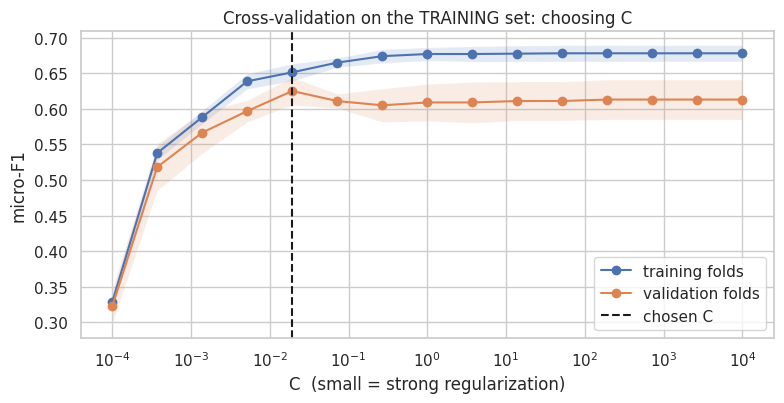

In [17]:
# Look at all 15 candidates
cv_table = pd.DataFrame({
    "C": param_grid["model__C"],
    "CV micro-F1 (validation folds)": lr_search.cv_results_["mean_test_score"],
    "CV micro-F1 (training folds)":   lr_search.cv_results_["mean_train_score"],
    "rank": lr_search.cv_results_["rank_test_score"],
})
display(cv_table.round(4))

C_values   = param_grid["model__C"]
val_mean   = lr_search.cv_results_["mean_test_score"];  val_std   = lr_search.cv_results_["std_test_score"]
train_mean = lr_search.cv_results_["mean_train_score"]; train_std = lr_search.cv_results_["std_train_score"]

plt.figure(figsize=(8, 4.2))
plt.plot(C_values, train_mean, "o-", label="training folds")
plt.plot(C_values, val_mean,   "o-", label="validation folds")
plt.fill_between(C_values, train_mean - train_std, train_mean + train_std, alpha=0.15)
plt.fill_between(C_values, val_mean - val_std,     val_mean + val_std,     alpha=0.15)
plt.axvline(lr_search.best_params_["model__C"], color="k", linestyle="--", label="chosen C")
plt.xscale("log"); plt.xlabel("C  (small = strong regularization)"); plt.ylabel("micro-F1")
plt.title("Cross-validation on the TRAINING set: choosing C")
plt.legend(); plt.tight_layout(); plt.show()

**How to read this plot.** On the left (tiny `C`) the model is over-simplified (*underfitting*): both curves are low. Moving right, the model becomes more flexible and the validation curve rises, then flattens or falls while the training curve keeps rising — the sign of *overfitting*. We pick the `C` where the **validation** curve is best.

**Convergence and integrity checks.**

In [18]:
best_pipeline = lr_search.best_estimator_            # preprocessing + model, already re-trained on all training data
lr_model      = best_pipeline.named_steps["model"]

# 1) Did the optimizer converge before running out of iterations?
print("max_iter allowed      :", lr_model.max_iter)
print("iterations actually used:", lr_model.n_iter_)
assert lr_model.n_iter_.max() < lr_model.max_iter, "The optimizer hit max_iter: increase max_iter."

# 2) Leakage check: the preprocessing steps must have learned from the TRAINING data only
fitted_imputer = best_pipeline.named_steps["imputer"]
fitted_scaler  = best_pipeline.named_steps["scaler"]
train_medians  = X_train.median()
assert np.allclose(fitted_imputer.statistics_, train_medians.values), "Imputer was not fitted on training data only!"
imputed_train = X_train.fillna(train_medians)
assert np.allclose(fitted_scaler.mean_, imputed_train.mean().values), "Scaler was not fitted on training data only!"
print("Leakage check passed: imputer medians and scaler means come from the training rows only.")

# 3) It really is a multinomial (softmax) model: one weight vector per class
print("Classes learned by the model:", lr_model.classes_)
print("Coefficient matrix shape (classes x features):", lr_model.coef_.shape)

max_iter allowed      : 5000
iterations actually used: [11]
Leakage check passed: imputer medians and scaler means come from the training rows only.
Classes learned by the model: [1 2 3 5]
Coefficient matrix shape (classes x features): (4, 20)


## 15. Make Predictions

We now predict the regime for **both** the training sites and the test sites. (The test predictions are what we use for the honest evaluation.) We also ask for the predicted **probabilities** — the softmax outputs — for a few test sites.

In [19]:
# lr_search.predict() automatically applies the fitted pipeline: impute -> scale -> model
lr_train_pred = lr_search.predict(X_train)
lr_test_pred  = lr_search.predict(X_test)

# Probabilities (softmax): one column per regime, each row adds up to 1
proba = lr_search.predict_proba(X_test)
assert np.allclose(proba.sum(axis=1), 1.0)

preview = pd.DataFrame(proba[:8], columns=[f"P({n})" for n in class_names], index=X_test.index[:8]).round(3)
preview.insert(0, "true regime", y_test.iloc[:8].values)
preview.insert(1, "predicted", lr_test_pred[:8])
preview

,true regime,predicted,P(Regime 1),P(Regime 2),P(Regime 3),P(Regime 5)
361,5,5,0.030,0.056,0.177,0.738
217,1,2,0.207,0.608,0.085,0.100
506,1,1,0.453,0.088,0.261,0.198
255,1,3,0.111,0.054,0.550,0.285
593,1,1,0.798,0.136,0.027,0.039
557,1,1,0.751,0.071,0.107,0.071
530,1,1,0.684,0.237,0.019,0.061
331,3,5,0.052,0.031,0.329,0.587


## 16. Evaluation

Now we measure how good the predictions are.
**Training performance vs. test performance — an important difference**

* **Training** scores tell us how well the model fits sites it *has already seen*. They are usually too optimistic.
* **Test** scores tell us how well it works on *new* sites. **Only the test score is the honest measure of performance.**
* A big gap (training much higher than test) is a sign of **overfitting**.

Below, every table labels clearly which numbers are TRAIN and which are TEST. We also report the **cross-validation (CV)** score from the training set, which is the score that was used to choose the settings.

In [ ]:
results = {}    # we will collect the final numbers here

## 17. Accuracy — Logistic Regression

**Accuracy** = (number of correct predictions) ÷ (total number of predictions). Easy to understand, but it can be misleading when classes are very unequal in size (here they are fairly similar).

In [20]:
lr_acc_train = accuracy_score(y_train, lr_train_pred)
lr_acc_test  = accuracy_score(y_test,  lr_test_pred)

print("Logistic Regression - ACCURACY")
print(f"  TRAIN (optimistic)       : {lr_acc_train:.3f}")
print(f"  CV on train (selection)  : {lr_search.best_score_:.3f}   (5-fold CV micro-F1, which equals accuracy)")
print(f"  TEST  (honest estimate)  : {lr_acc_test:.3f}")
print(f"  Test sites misclassified : {int((y_test.to_numpy() != lr_test_pred).sum())} out of {len(y_test)}")

Logistic Regression - ACCURACY
  TRAIN (optimistic)       : 0.663
  CV on train (selection)  : 0.625   (5-fold CV micro-F1, which equals accuracy)
  TEST  (honest estimate)  : 0.589
  Test sites misclassified : 51 out of 124


## 18. Precision — Logistic Regression

**Precision** (for one regime) answers: *"When the model says Regime k, how often is it right?"* = true positives ÷ (true positives + false positives).

With 4 classes we need to *average* the four per-class precisions:
* **macro** average = simple mean of the 4 values (every regime counts equally),
* **weighted** average = mean weighted by how many sites each regime has.

In [21]:
lr_prec_train_macro = precision_score(y_train, lr_train_pred, average="macro",    zero_division=0)
lr_prec_train_wtd   = precision_score(y_train, lr_train_pred, average="weighted", zero_division=0)
lr_prec_test_macro  = precision_score(y_test,  lr_test_pred,  average="macro",    zero_division=0)
lr_prec_test_wtd    = precision_score(y_test,  lr_test_pred,  average="weighted", zero_division=0)

print("Logistic Regression - PRECISION")
print(pd.DataFrame({"macro": [lr_prec_train_macro, lr_prec_test_macro],
                    "weighted": [lr_prec_train_wtd, lr_prec_test_wtd]},
                   index=["TRAIN (optimistic)", "TEST (honest)"]).round(3).to_string())

Logistic Regression - PRECISION
                    macro  weighted
TRAIN (optimistic)  0.664     0.666
TEST (honest)       0.574     0.601


## 19. Recall — Logistic Regression

**Recall** (for one regime) answers: *"Of all the sites that truly are Regime k, how many did the model find?"* = true positives ÷ (true positives + false negatives).

In [22]:
lr_rec_train_macro = recall_score(y_train, lr_train_pred, average="macro",    zero_division=0)
lr_rec_train_wtd   = recall_score(y_train, lr_train_pred, average="weighted", zero_division=0)
lr_rec_test_macro  = recall_score(y_test,  lr_test_pred,  average="macro",    zero_division=0)
lr_rec_test_wtd    = recall_score(y_test,  lr_test_pred,  average="weighted", zero_division=0)

print("Logistic Regression - RECALL")
print(pd.DataFrame({"macro": [lr_rec_train_macro, lr_rec_test_macro],
                    "weighted": [lr_rec_train_wtd, lr_rec_test_wtd]},
                   index=["TRAIN (optimistic)", "TEST (honest)"]).round(3).to_string())

Logistic Regression - RECALL
                    macro  weighted
TRAIN (optimistic)  0.659     0.663
TEST (honest)       0.560     0.589


## 20. F1 Score — Logistic Regression

**F1** combines precision and recall into one number (their harmonic mean), so a model only gets a high F1 if *both* are high: `F1 = 2 · precision · recall / (precision + recall)`. Again we show the macro and weighted averages over the four regimes.

In [23]:
lr_f1_train_macro = f1_score(y_train, lr_train_pred, average="macro",    zero_division=0)
lr_f1_train_wtd   = f1_score(y_train, lr_train_pred, average="weighted", zero_division=0)
lr_f1_test_macro  = f1_score(y_test,  lr_test_pred,  average="macro",    zero_division=0)
lr_f1_test_wtd    = f1_score(y_test,  lr_test_pred,  average="weighted", zero_division=0)

print("Logistic Regression - F1 SCORE")
print(pd.DataFrame({"macro": [lr_f1_train_macro, lr_f1_test_macro],
                    "weighted": [lr_f1_train_wtd, lr_f1_test_wtd]},
                   index=["TRAIN (optimistic)", "TEST (honest)"]).round(3).to_string())

Logistic Regression - F1 SCORE
                    macro  weighted
TRAIN (optimistic)  0.655     0.658
TEST (honest)       0.561     0.590


## 21. Micro-average F1 — Logistic Regression  ⭐ (main metric)

**Micro-average F1** pools *all* individual predictions together (all sites, all classes) and computes one precision, one recall and one F1 from the pooled counts.

For a problem where every site has exactly **one** true class and gets exactly **one** predicted class (like ours), micro-precision = micro-recall = micro-F1 = **accuracy**. We verify this below instead of just claiming it.

> **Note on the reference code:** the reference's helper `microaveage_F1()` actually returns the *weighted* average F1 (from the `weighted avg` row of the classification report), not the micro average. In this notebook the micro-average F1 is computed with `average="micro"`, and the weighted F1 is shown separately above.

Because the test set is small, the score has noticeable uncertainty. We estimate it with the standard error of a proportion: `sqrt(p · (1−p) / n)`.

In [24]:
lr_micro_train = f1_score(y_train, lr_train_pred, average="micro")
lr_micro_test  = f1_score(y_test,  lr_test_pred,  average="micro")
lr_micro_cv    = lr_search.best_score_    # the CV score used to choose settings (scoring="f1_micro")

# Check the claim "micro-precision = micro-recall = micro-F1 = accuracy"
mp = precision_score(y_test, lr_test_pred, average="micro")
mr = recall_score(y_test,    lr_test_pred, average="micro")
print("Check on TEST: micro-precision, micro-recall, micro-F1, accuracy =",
      round(mp, 4), round(mr, 4), round(lr_micro_test, 4), round(lr_acc_test, 4))
assert np.isclose(mp, lr_micro_test) and np.isclose(mr, lr_micro_test) and np.isclose(lr_micro_test, lr_acc_test)

se = np.sqrt(lr_micro_test * (1 - lr_micro_test) / len(y_test))
print()
print("Logistic Regression - MICRO-AVERAGE F1")
print(f"  TRAIN (optimistic)       : {lr_micro_train:.3f}")
print(f"  CV on train (selection)  : {lr_micro_cv:.3f}")
print(f"  TEST  (honest estimate)  : {lr_micro_test:.3f}   (approx. standard error +/- {se:.3f}, n = {len(y_test)} test sites)")
print(f"  Weighted F1 on TEST (what the reference helper function calls 'micro'): {lr_f1_test_wtd:.3f}")

Check on TEST: micro-precision, micro-recall, micro-F1, accuracy = 0.5887 0.5887 0.5887 0.5887

Logistic Regression - MICRO-AVERAGE F1
  TRAIN (optimistic)       : 0.663
  CV on train (selection)  : 0.625
  TEST  (honest estimate)  : 0.589   (approx. standard error +/- 0.044, n = 124 test sites)
  Weighted F1 on TEST (what the reference helper function calls 'micro'): 0.590


## 22. Confusion Matrix — Logistic Regression

A **confusion matrix** shows, for each *true* regime (rows), which regime the model *predicted* (columns). Numbers on the diagonal are correct predictions; everything off the diagonal is a mistake — and it shows *which* regimes get confused with each other.

* Left: **TRAIN** (counts) &nbsp;|&nbsp; Middle: **TEST** (counts) &nbsp;|&nbsp; Right: **TEST** as a fraction of each true regime (the diagonal is that regime's recall).

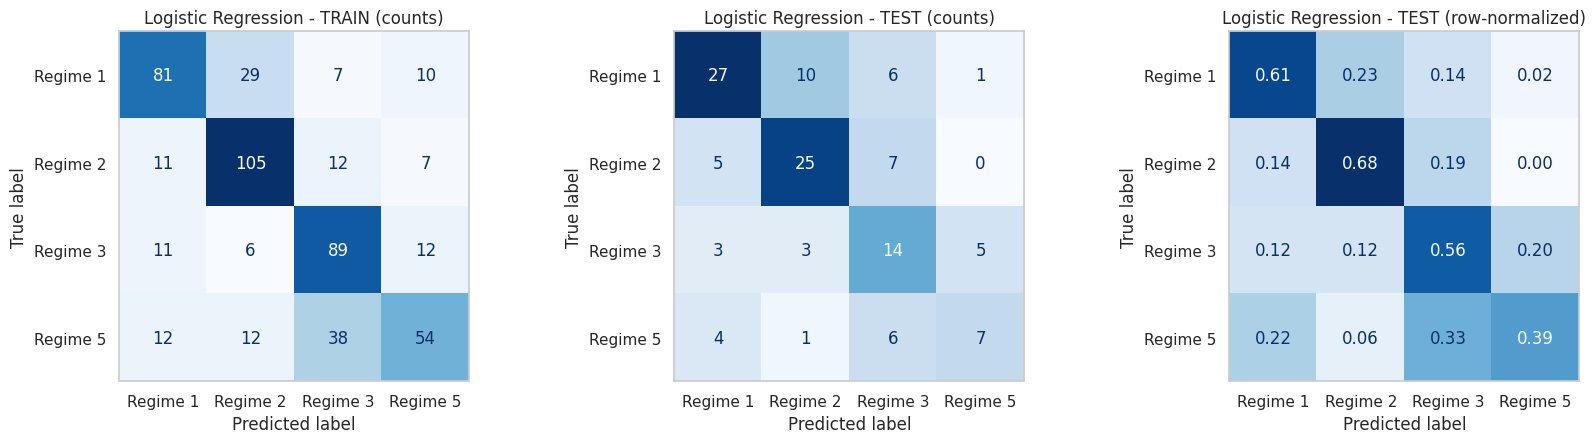

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))

ConfusionMatrixDisplay.from_predictions(y_train, lr_train_pred, labels=class_labels, display_labels=class_names,
                                        cmap="Blues", ax=axes[0], colorbar=False)
axes[0].set_title("Logistic Regression - TRAIN (counts)")

ConfusionMatrixDisplay.from_predictions(y_test, lr_test_pred, labels=class_labels, display_labels=class_names,
                                        cmap="Blues", ax=axes[1], colorbar=False)
axes[1].set_title("Logistic Regression - TEST (counts)")

ConfusionMatrixDisplay.from_predictions(y_test, lr_test_pred, labels=class_labels, display_labels=class_names,
                                        normalize="true", values_format=".2f", cmap="Blues", ax=axes[2], colorbar=False)
axes[2].set_title("Logistic Regression - TEST (row-normalized)")

for ax in axes:
    ax.grid(False)
plt.tight_layout(); plt.show()

## 23. Classification Report — Logistic Regression

The classification report lists precision, recall and F1 **for each regime separately**, plus the averages. `support` is the number of real sites of that regime in the data being evaluated.

In [28]:
print("=" * 70)
print("Logistic Regression - classification report on the TRAINING set (optimistic)")
print("=" * 70)
print(classification_report(y_train, lr_train_pred, labels=class_labels, target_names=class_names, digits=3, zero_division=0))

print("=" * 70)
print("Logistic Regression - classification report on the TEST set (honest estimate)")
print("=" * 70)
print(classification_report(y_test, lr_test_pred, labels=class_labels, target_names=class_names, digits=3, zero_division=0))

results = {}
# Keep the numbers for the final summary
results["Logistic Regression"] = {
    "Micro-F1 (= accuracy) TRAIN": lr_micro_train,
    "Micro-F1 CV (5-fold, train)": lr_micro_cv,
    "Micro-F1 TEST": lr_micro_test,
    "Macro precision TEST": lr_prec_test_macro,
    "Macro recall TEST": lr_rec_test_macro,
    "Macro F1 TEST": lr_f1_test_macro,
    "Weighted F1 TEST": lr_f1_test_wtd,
}

Logistic Regression - classification report on the TRAINING set (optimistic)
              precision    recall  f1-score   support

    Regime 1      0.704     0.638     0.669       127
    Regime 2      0.691     0.778     0.732       135
    Regime 3      0.610     0.754     0.674       118
    Regime 5      0.651     0.466     0.543       116

    accuracy                          0.663       496
   macro avg      0.664     0.659     0.655       496
weighted avg      0.666     0.663     0.658       496

Logistic Regression - classification report on the TEST set (honest estimate)
              precision    recall  f1-score   support

    Regime 1      0.692     0.614     0.651        44
    Regime 2      0.641     0.676     0.658        37
    Regime 3      0.424     0.560     0.483        25
    Regime 5      0.538     0.389     0.452        18

    accuracy                          0.589       124
   macro avg      0.574     0.560     0.561       124
weighted avg      0.601     0.

## 24. Results Interpretation

The cell below writes a short summary **directly from the numbers computed above** (so it always matches the results, whatever they turn out to be).

In [29]:
# --- Numbers we need ---
test_micro  = lr_micro_test
train_micro = lr_micro_train
cv_micro    = lr_micro_cv
gap         = train_micro - test_micro
se          = np.sqrt(test_micro * (1 - test_micro) / len(y_test))

dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
baseline_test = accuracy_score(y_test, dummy.predict(X_test))
majority_class = int(dummy.classes_[np.argmax(dummy.class_prior_)])

per_class_f1 = f1_score(y_test, lr_test_pred, labels=class_labels, average=None, zero_division=0)
best_class, worst_class = class_labels[int(np.argmax(per_class_f1))], class_labels[int(np.argmin(per_class_f1))]

cm = confusion_matrix(y_test, lr_test_pred, labels=class_labels)
off = cm.copy(); np.fill_diagonal(off, 0)
i, j = np.unravel_index(off.argmax(), off.shape)

print(f"1. Overall: on {len(y_test)} unseen test sites the model gets micro-F1 = {test_micro:.3f} "
      f"(about +/- {se:.3f}), i.e. {int(round(test_micro*len(y_test)))} sites correct.")
print(f"2. Compared with simply always guessing the most common regime in the training data (Regime {majority_class}), "
      f"which scores {baseline_test:.3f} on the test set, the model is "
      f"{'better' if test_micro > baseline_test else 'NOT better'} by {abs(test_micro - baseline_test):.3f}.")
print(f"3. Training vs test: TRAIN micro-F1 = {train_micro:.3f}, CV = {cv_micro:.3f}, TEST = {test_micro:.3f}. "
      f"Train - test gap = {gap:+.3f}"
      + (" -> noticeably higher on training data (some overfitting)." if gap > 0.10
         else " -> small gap: the model is not strongly overfitting (a simple model with regularization)."))
print(f"4. Easiest regime to recognize on the test set: Regime {best_class} (F1 = {per_class_f1.max():.3f}); "
      f"hardest: Regime {worst_class} (F1 = {per_class_f1.min():.3f}).")
print(f"5. Most frequent confusion: true Regime {class_labels[i]} predicted as Regime {class_labels[j]} ({off[i, j]} test sites).")

1. Overall: on 124 unseen test sites the model gets micro-F1 = 0.589 (about +/- 0.044), i.e. 73 sites correct.
2. Compared with simply always guessing the most common regime in the training data (Regime 2), which scores 0.298 on the test set, the model is better by 0.290.
3. Training vs test: TRAIN micro-F1 = 0.663, CV = 0.625, TEST = 0.589. Train - test gap = +0.075 -> small gap: the model is not strongly overfitting (a simple model with regularization).
4. Easiest regime to recognize on the test set: Regime 2 (F1 = 0.658); hardest: Regime 5 (F1 = 0.452).
5. Most frequent confusion: true Regime 1 predicted as Regime 2 (10 test sites).


### Which predictors matter most to the model?

Because we standardized the features, the model's **coefficients are directly comparable**: a coefficient far from 0 means that feature pushes the prediction strongly towards (positive) or away from (negative) that regime, *holding the other features fixed*. This is the main advantage of logistic regression — it is interpretable.

> ⚠️ **Treat this as exploratory, not as proof of cause.** Many predictors are correlated with each other (neighbouring sites share similar environments), and regularization shrinks and shares weight between correlated predictors. Coefficients show what the model *uses*, not what *causes* a regime.

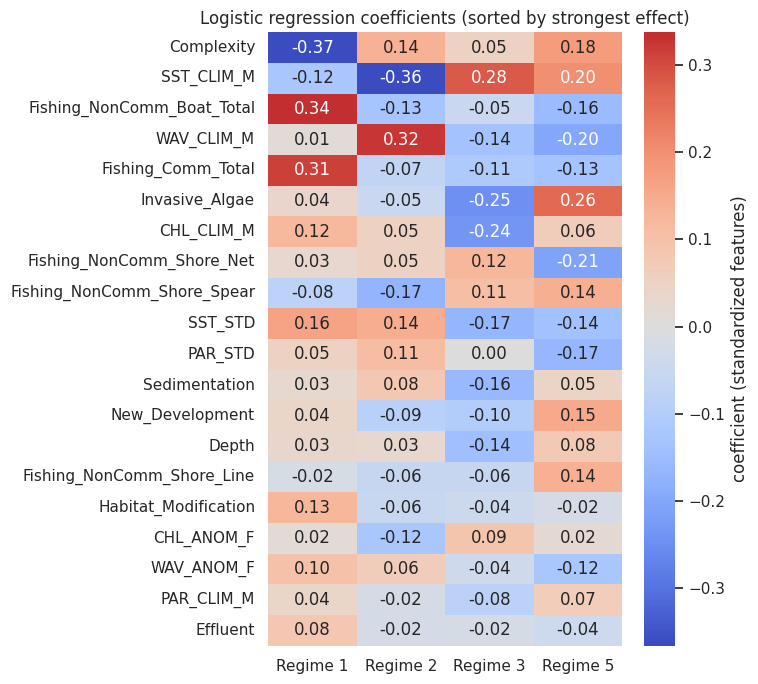

Average |coefficient| per predictor group:
Anthropogenic (human) predictors    0.105
Biophysical (natural) predictors    0.121

Top 5 predictors by strongest effect: ['Complexity', 'SST_CLIM_M', 'Fishing_NonComm_Boat_Total', 'WAV_CLIM_M', 'Fishing_Comm_Total']


In [30]:
coef_df = pd.DataFrame(lr_model.coef_.T, index=FEATURES, columns=class_names)
coef_df["max |coef|"] = coef_df[class_names].abs().max(axis=1)
coef_df = coef_df.sort_values("max |coef|", ascending=False)

plt.figure(figsize=(7.5, 7))
sns.heatmap(coef_df[class_names], annot=True, fmt=".2f", cmap="coolwarm", center=0, cbar_kws={"label": "coefficient (standardized features)"})
plt.title("Logistic regression coefficients (sorted by strongest effect)")
plt.tight_layout(); plt.show()

# Average size of the coefficients for human vs natural predictors
mean_abs = coef_df[class_names].abs().mean(axis=1)
group_means = pd.Series({
    "Anthropogenic (human) predictors": mean_abs[ANTHROPOGENIC].mean(),
    "Biophysical (natural) predictors": mean_abs[BIOPHYSICAL].mean(),
})
print("Average |coefficient| per predictor group:")
print(group_means.round(3).to_string())
print()
print("Top 5 predictors by strongest effect:", coef_df.index[:5].tolist())

## 25. Conclusion

In [31]:
print("=" * 72)
print("FINAL SUMMARY - Multinomial Logistic Regression (all numbers computed above)")
print("=" * 72)
print(f"Data           : {len(X)} sites, {X.shape[1]} features, classes {class_labels}")
print(f"Split          : {len(X_train)} train / {len(X_test)} test (random_state={SPLIT_RANDOM_STATE})")
print(f"Preprocessing  : median imputation + standardization, fitted on training data only (Pipeline)")
print(f"Model          : multinomial logistic regression (L2), C = {lr_search.best_params_['model__C']:.5g} chosen by 5-fold CV")
print()
summary = pd.DataFrame(results).T
display(summary.round(3))
print(f"\nHEADLINE (main metric)  TEST micro-average F1 = {lr_micro_test:.3f}")

FINAL SUMMARY - Multinomial Logistic Regression (all numbers computed above)
Data           : 620 sites, 20 features, classes [1, 2, 3, 5]
Split          : 496 train / 124 test (random_state=47)
Preprocessing  : median imputation + standardization, fitted on training data only (Pipeline)
Model          : multinomial logistic regression (L2), C = 0.019307 chosen by 5-fold CV



,Micro-F1 (= accuracy) TRAIN,"Micro-F1 CV (5-fold, train)",Micro-F1 TEST,Macro precision TEST,Macro recall TEST,Macro F1 TEST,Weighted F1 TEST
Logistic Regression,0.663,0.625,0.589,0.574,0.56,0.561,0.59



HEADLINE (main metric)  TEST micro-average F1 = 0.589


### What we did
We predicted four coral reef regimes from 20 human and natural predictors with a **multinomial logistic regression**. Missing `Complexity`/`Depth` values were filled with training-data medians, features were standardized, and the regularization strength `C` was chosen by 5-fold cross-validation on the training set only. All preprocessing lives in a `Pipeline`, so no information from the test set reached the model. The final model was evaluated once on the held-out test set using micro-average F1 as the main metric, supported by accuracy, precision, recall, macro/weighted F1, confusion matrices and a per-class report.

### What the results tell us
Use the **FINAL SUMMARY** table and the interpretation in section 24: (1) is the test micro-F1 clearly above the "always guess the most common regime" baseline? (2) how large is the train–test gap? (3) which regimes are hardest, and which regimes get confused with each other? Because logistic regression draws only *straight-line (linear)* boundaries between regimes, regimes that overlap in a non-linear way will be confused; a more flexible model (the SVM in Notebook 02, or tree-based models) may separate them better.

### Limitations
* **Small data:** a few hundred sites; the test set is small, so scores carry noticeable uncertainty (see the +/- value in section 21).
* **Imputation:** a constant fill for `Complexity` (missing for roughly a fifth of sites) reduces that feature's usefulness.
* **Linear model:** logistic regression cannot capture interactions or curved relationships on its own.
* **Spatial dependence:** nearby sites are similar, so a random split may be slightly optimistic about performance in a new area.

### Why our results may differ from the reference project's results

It is perfectly fine (and expected) if our numbers differ. Possible reasons:

1. **Different missing-value handling.** The reference's final data file filled `Complexity` with a Lasso model trained on all sites *before* splitting (leakage); we use a training-only median inside the pipeline.
2. **Different thing being reported.** The reference's results table mainly shows *cross-validation* scores on the training + validation data. Our headline number is the score on a *held-out test set*.
3. **Their "micro-average F1" helper function actually computes the *weighted* average F1** (it reads the `weighted avg` line of the classification report). We compute the true micro-average F1 (which, for single-label multi-class problems, equals accuracy) and also report the weighted F1 separately.
4. **Hyper-parameter tuning.** We tune settings with cross-validation and scikit-learn today uses different defaults (and different optimizers) than the old scikit-learn version the reference used (for example, the SVM `gamma` default changed).
5. **Random splits and a small dataset.** With only a few hundred sites, a handful of sites can change a score by several percentage points. Different random seeds for cross-validation or a different split give different numbers.
6. **Spatial dependence.** Neighbouring reef sites often share almost identical environmental values (several predictors are the same for nearby sites). A random split can therefore place near-duplicates in both train and test sets, which can make results look slightly better than they would on a truly new region.
7. **Software versions.** Different scikit-learn / NumPy versions can change numerical details.